# Logistic Regression - IT22253644

individual contribution: cancellation prediction using Logistic Regression.

Dataset = hotel_booking.csv

In [1]:
# Cell 1 - Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, average_precision_score, f1_score
 )
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# Cell 2 - Load dataset
df = pd.read_csv('hotel_bookings.csv')

print('Shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Shape: (119390, 32)

First 5 rows:


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [3]:
# Cell 3 - Quick overview
print('Column names:')
print(df.columns.tolist())

print('\nData types:')
print(df.dtypes)

print('\nMissing values:')
print(df.isnull().sum()[df.isnull().sum() > 0])

Column names:
['hotel', 'is_canceled', 'lead_time', 'arrival_date_year', 'arrival_date_month', 'arrival_date_week_number', 'arrival_date_day_of_month', 'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children', 'babies', 'meal', 'country', 'market_segment', 'distribution_channel', 'is_repeated_guest', 'previous_cancellations', 'previous_bookings_not_canceled', 'reserved_room_type', 'assigned_room_type', 'booking_changes', 'deposit_type', 'agent', 'company', 'days_in_waiting_list', 'customer_type', 'adr', 'required_car_parking_spaces', 'total_of_special_requests', 'reservation_status', 'reservation_status_date']

Data types:
hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nigh

In [4]:
# Cell 4 - Check missing values (imputation will be done inside the pipeline)
print('Missing values before modeling:')
print(df.isnull().sum()[df.isnull().sum() > 0])

print('\nTotal missing values:', df.isnull().sum().sum())

Missing values before modeling:
children         4
country        488
agent        16340
company     112593
dtype: int64

Total missing values: 129425


In [5]:
# Cell 5 - Drop leakage and non-direct date column
df = df.drop(['reservation_status', 'reservation_status_date'], axis=1)

print('Remaining columns:', df.shape[1])

Remaining columns: 30


In [6]:
# Cell 6 - Identify categorical and numerical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').drop('is_canceled', axis=1).columns.tolist()

print('Categorical columns:', len(cat_cols))
print('Numerical columns:', len(num_cols))
print('Sample categorical columns:', cat_cols[:8])

Categorical columns: 10
Numerical columns: 19
Sample categorical columns: ['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment', 'distribution_channel', 'reserved_room_type', 'assigned_room_type']


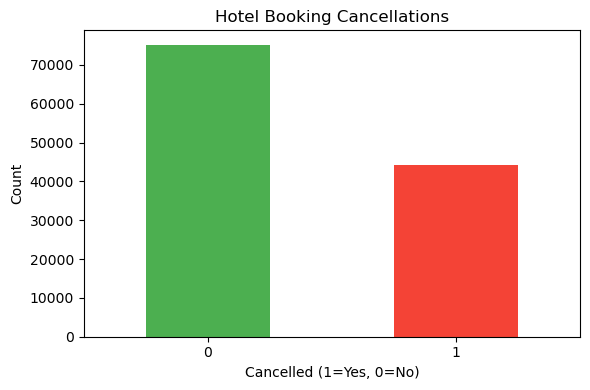

Cancellation rate: 37.04 %


In [7]:
# Cell 7 - Target variable distribution
plt.figure(figsize=(6, 4))
df['is_canceled'].value_counts().plot(kind='bar', color=['#4CAF50', '#F44336'])
plt.title('Hotel Booking Cancellations')
plt.xlabel('Cancelled (1=Yes, 0=No)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print('Cancellation rate:', round(df['is_canceled'].mean() * 100, 2), '%')